# Practice — 디버깅 (Debugging)

간단한 CNN 학습 코드를 **한 줄씩 멈춰 가며** 들여다보고, 오류가 난 모델을 직접 고친다.

- 환경: **VS Code** — 중단점과 Debug Cell 이 필요하다

---
# 1. 준비

- 데이터: MNIST 학습 이미지 60000 장 — 변환은 텐서로 바꾸는 것 하나
- 한 배치: 이미지 `(64, 1, 28, 28)`, 정답 `(64,)`
- `train` : 배치마다 forward → loss → `backward()` → `step()`

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_set = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

In [2]:
def train(model, train_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)               # logits, (batch, 10)
            loss = criterion(output, Y_batch)

            optimizer.zero_grad()                 # 누적된 기울기를 지운다
            loss.backward()                       # autograd 가 기울기를 계산
            optimizer.step()                      # optimizer 가 파라미터를 갱신

---
# 2. 간단한 CNN

conv 두 층 + linear 한 층. 같은 모델을 두 가지 방식으로 적었다.

| 항목 | 방법 1 — `nn.Sequential` | 방법 2 — 한 줄에 한 연산 |
|------|--------------------------|--------------------------|
| 코드 | 짧다 | 길다 |
| 디버거로 중간 결과 보기 | `forward` 가 한 줄 → 층 사이에서 멈출 수 없다 | 줄마다 멈춰 `out` 을 볼 수 있다 |

- 두 셀 모두 `SimpleCNN` 을 정의한다 → **나중에 실행한 셀**이 쓰인다
- 한쪽만 쓰려면 다른 셀을 마크다운으로 바꾼다

In [3]:
# 방법 1 - nn.Sequential 로 층을 차례로 나열한다
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(6 * 7 * 7, 10),
        )

    def forward(self, x):
        out = self.net(x)             # logits - 모든 층이 이 한 줄에서 실행된다
        return out

In [4]:
# 방법 2 - 층을 하나씩 만들고, forward 에서 한 줄에 한 연산씩 부른다
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 7 * 7, 10)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)

        out = out.flatten(1)
        out = self.fc(out)            # logits
        return out

In [5]:
torch.manual_seed(42)
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

---
# 3. 디버거 사용

| 하려는 것 | 조작 |
|-----------|------|
| 멈출 곳 정하기 (중단점) | 줄 번호 왼쪽을 클릭 → 빨간 점 |
| 디버깅 시작 | 실행 버튼 옆 작은 화살표 → **Debug Cell** |
| 다음 줄로 | `F10` (Step Over) |
| 이 줄이 부르는 함수 **안으로** | `F11` (Step Into) |
| 지금 함수를 끝내고 **부른 곳**으로 | `Shift+F11` (Step Out) |
| 다음 중단점까지 실행 | `F5` (Continue) |
| 값 보기 | VARIABLES 창에서 텐서를 펼쳐 `shape` 확인. WATCH 창에 `out.shape` 같은 식을 등록해 두면 멈출 때마다 다시 계산된다 |
| 선택한 코드를 바로 실행 | 코드를 드래그해 선택 → 우클릭 → **Evaluate in Debug Console** (기본 단축키 없음 → 아래에서 지정) |

- 노랗게 표시된 줄은 **아직 실행 전**이다

### 단축키 지정 — Evaluate in Debug Console

1. `Ctrl+Shift+P` → `shortcut` 검색 → **Preferences: Open Keyboard Shortcuts** 선택
2. 검색창에 `Evaluate in Debug Console` 입력
3. 항목을 더블클릭 → 원하는 키(예: `F9`)를 누르고 `Enter`

- `F9` 는 원래 중단점을 거는 키다 → 이 키로 바꾸면 중단점은 줄 번호 왼쪽 클릭으로 건다

---
# 4. 오류 — `fc` 의 입력 크기

- `SimpleCNN` 과 같은 모델인데 `fc` 의 입력 크기만 다르게 적었다 → 실행하면 오류가 난다
- 디버거로 원인을 확인하고 고친다 (힌트는 코드의 주석)
- 모델 셀을 고친 뒤 그 셀과 아래 학습 셀을 다시 실행 → 오류 없이 끝나면 성공

In [6]:
class FcErrorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 14 * 14, 10)    # 입력 크기가 틀렸다

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)

        out = out.flatten(1)
        out = self.fc(out)            # logits (오류가 나는 줄)
        # 왜 오류인가   : fc 가 기대하는 입력 크기(6 * 14 * 14)와 flatten 뒤 out 의 크기가 다르다.
        # 어떻게 고치나 : 이 줄에 중단점을 걸어 out.shape 을 확인하고, fc 의 입력 크기를 6 * 7 * 7 로 바꾼다.
        return out

In [7]:
torch.manual_seed(42)
model = FcErrorCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x294 and 1176x10)

---
# 5. 오류 — Residual connection

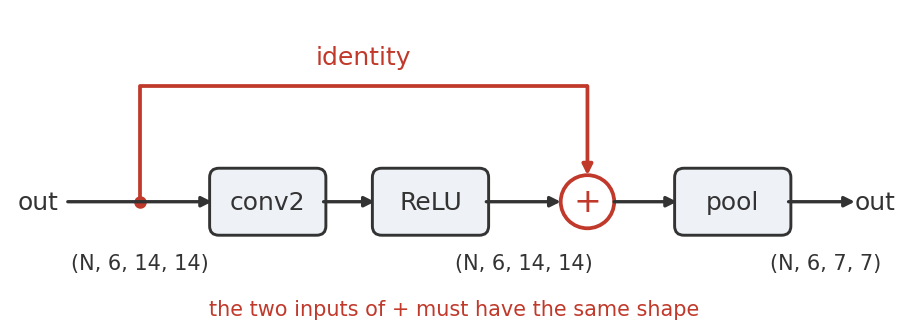

- `identity` : 블록에 들어가기 전의 값을 잡아 두었다가 블록의 출력에 더한다
- 그림은 **올바른 구조**다. 아래 코드는 덧셈의 위치가 그림과 달라 오류가 난다 (힌트는 코드의 주석)

In [8]:
class ResidualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(6, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(6 * 7 * 7, 10)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.pool(out)

        identity = out                # 나중에 더할 값을 잡아 둔다
        out = self.conv2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = out + identity          # residual connection (오류가 나는 줄)
        # 왜 오류인가   : out 과 identity 의 가로·세로 크기가 다르다. pool 이 크기를 절반으로 줄인 뒤에 더했다.
        # 어떻게 고치나 : 덧셈을 pool 앞으로 옮긴다 (conv2 -> relu -> + identity -> pool).

        out = out.flatten(1)
        out = self.fc(out)            # logits
        return out

In [9]:
torch.manual_seed(42)
model = ResidualCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)

RuntimeError: The size of tensor a (7) must match the size of tensor b (14) at non-singleton dimension 3

---
# 6. `train` 이 별도 `.py` 파일에 있을 때

- `train_py.py` : 1절의 `train` 과 같은 함수가 들어 있다 (이 노트북과 같은 폴더)
- `train_py.py` 를 열어 중단점을 걸고 아래 학습 셀을 Debug Cell 로 실행 → **`.py` 파일 안에서도** 멈춘다
- `.py` 파일을 고친 뒤에는 커널을 다시 시작해야 반영된다
- 노트북의 `train` 으로 돌아가려면 1절의 `train` 셀을 다시 실행한다

In [10]:
from train_py import train    # 이제 train 은 train_py.py 에 있는 함수다

In [11]:
torch.manual_seed(42)
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train(model, train_loader, optimizer, epochs=1, device=device)